,run_number,prompt_num,clean,corrupted,restored_token,restored
0,1,0,"(' French', 0.4274365305900574)","(' a', 0.010471301153302193)",2,"[(' a', 0.005145118571817875), (' a', 0.000965..."
1,1,0,"(' French', 0.4274365305900574)","(' a', 0.010471301153302193)",3,"[(' the', 0.0003481079183984548), (' a', 0.000..."
2,1,0,"(' French', 0.4274365305900574)","(' a', 0.010471301153302193)",4,"[(' a', 0.0001035482418956235), (' a', 4.99770..."
3,2,5,"(' Dutch', 0.20871536433696747)","(' a', 8.635283302282915e-05)",1,"[(' a', 0.0001252513175131753), (' a', 0.00025..."
4,2,5,"(' Dutch', 0.20871536433696747)","(' a', 8.635283302282915e-05)",2,"[(' a', 4.129474109504372e-05), (' a', 4.06677..."
...,...,...,...,...,...,...
3997,1000,10084,"(' French', 0.4435661733150482)","(' a', 0.00016037335444707423)",1,"[(' a', 0.000796071661170572), (' a', 0.000597..."
3998,1000,10084,"(' French', 0.4435661733150482)","(' a', 0.00016037335444707423)",2,"[(' a', 0.0006814646767452359), (' a', 0.00182..."
3999,1000,10084,"(' French', 0.4435661733150482)","(' a', 0.00016037335444707423)",3,"[(' a', 0.000214731931919232), (' a', 0.000507..."
4000,1000,10084,"(' French', 0.4435661733150482)","(' a', 0.00016037335444707423)",4,"[(' a', 0.002082114340737462), (' a', 0.001204..."


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
run_number,,,,,,,,,,,,,,,,,,,,,
1,-0.005326,-0.009506,0.003115,-0.003338,-0.008927,-0.005898,-0.002426,0.032766,-0.009557,-0.009257,...,-0.009435,-0.008375,-0.010326,-0.010319,-0.009526,-0.010362,-9.997900e-03,-0.010294,-0.010370,-0.009982
2,0.000076,0.000171,0.000076,-0.000020,0.000108,0.000028,-0.000021,0.000215,-0.000026,-0.000044,...,-0.000001,0.000030,0.000118,0.000031,-0.000012,0.000009,-3.610586e-05,-0.000032,0.000445,0.000095
3,0.009745,0.008678,0.001351,0.007975,0.000828,0.009397,0.004980,0.014570,0.014621,0.023125,...,0.000924,0.018826,0.001616,0.000405,0.005598,0.000637,3.304189e-03,0.000580,0.006424,0.000580
4,0.000580,0.005933,0.002756,0.017531,0.004141,0.052433,0.006305,0.030875,0.017127,0.037937,...,0.001095,0.001750,0.000268,0.000425,0.001312,0.001206,-8.188153e-05,0.000970,0.000335,-0.000197
5,0.001808,-0.001154,0.078848,0.161572,0.402756,0.379199,0.384492,0.423580,0.021777,0.013018,...,0.007123,-0.000389,-0.000197,0.000383,0.000431,-0.000084,-9.444754e-04,-0.001046,-0.001126,-0.000739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.006091,0.006964,0.016960,0.035884,0.001678,0.089670,0.006633,0.037752,0.000961,0.013322,...,0.000340,0.000078,0.000080,0.000006,0.000002,0.000025,1.574881e-07,0.000182,0.000005,0.000001
997,0.026334,0.012664,0.044928,0.005781,0.047653,0.007015,0.012306,0.025007,0.012885,0.002315,...,0.009985,0.010081,0.002701,0.011929,0.028231,0.102912,8.450025e-03,0.005151,0.018012,0.017385
998,0.007581,0.008286,0.014442,0.110549,0.044092,0.281658,0.065575,0.037358,0.109203,0.383666,...,-0.003959,0.054927,0.314051,0.166145,0.300907,-0.002422,1.152688e-02,-0.000320,0.005122,-0.006463


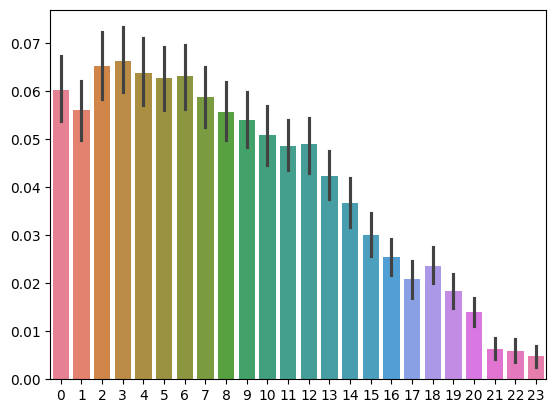

In [8]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

result_names = [
    # "results_2025-08-28_13-41-37_gpt2-xl",
    "results_2025-09-10_15-37-47_gpt2-medium"
]

for filename in result_names:
    df = pd.read_csv(f"{filename}.csv")

    display(df)

    df['clean'] = df['clean'].apply(ast.literal_eval)

    df['corrupted'] = df['corrupted'].apply(ast.literal_eval)
    df['restored'] = df['restored'].apply(ast.literal_eval)
    df_expanded = df['restored'].apply(pd.Series)

    df_final = pd.concat([df.drop('restored', axis=1), df_expanded], axis=1)
    df_final["clean_token"] = df_final["clean"].apply(lambda x: x[0])
    df_final["clean"] = df_final["clean"].apply(lambda x: x[1])

    df_ff = df_final
    df_ff["corrupted"] = df_ff["corrupted"].apply(lambda x: x[1])
    
    for i in range(24):
        df_ff[i] = df_ff[i].apply(lambda x: x[1])
        df_ff[i] = df_ff[i] - df_ff["corrupted"]

    df_preproc = df_ff
    df_preproc = df_preproc.drop('prompt_num', axis=1)
    df_preproc = df_preproc.drop('clean', axis=1)
    df_preproc = df_preproc.drop('corrupted', axis=1)
    df_p_g = df_preproc.groupby(["run_number"]).max(["restored_token"]).drop("restored_token", axis=1)

    display(df_p_g)

    sns.barplot(data=df_p_g)
    plt.show()
